# Alberta Wildfire RAG / GraphRAG Pipeline

**Goal:** Build a retrieval-augmented generation (RAG) and graph-RAG (GRAG) system over the wildfire reference documents.

**Sections:**
1. Install & configure
2. Load and chunk PDF documents
3. Embedding model grid search (MRR, Precision@k, Recall@k)
4. Save best embedding model + persistent ChromaDB vector store
5. Build Neo4j knowledge graph (documents → chunks → concepts)
6. Agentic RAG/GRAG assistant (ReAct loop)

**Ports used on this system (shared — do not rebind):**
- `11434` — Ollama (local, already running)
- `7687` — Neo4j Bolt (already running)
- `7474` — Neo4j HTTP browser

In [52]:
%pip install -q chromadb neo4j pypdf python-dotenv tqdm docker 2>&1 | tail -6

Note: you may need to restart the kernel to use updated packages.


'tail' is not recognized as an internal or external command,
operable program or batch file.


---
## Section 1 — Configuration

In [17]:
import os, json, re, time, textwrap
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from dotenv import load_dotenv
import chromadb
from neo4j import GraphDatabase
from pypdf import PdfReader
from IPython.display import display

load_dotenv(override=True)

# ── Ollama (local instance on port 11434 — do not change port) ──────────────
OLLAMA_LOCAL_URL = os.getenv("OLLAMA_LOCAL_URL", "http://localhost:11434")

# ── Neo4j (existing instance on port 7687 — do not rebind) ──────────────────
NEO4J_URI      = os.getenv("NEO4J_URI",      "bolt://localhost:7687")
NEO4J_USER     = os.getenv("NEO4J_USER",     "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DOCS_DIR    = Path("docs/data_docs")
VECTOR_STORE_DIR = Path("vector_store")
RESULTS_DIR      = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# ── Embedding models to evaluate (all confirmed present on local Ollama) ─────
EMBEDDING_MODELS = [
    "nomic-embed-text:latest",
    "mxbai-embed-large:latest",
    "bge-large:latest",
    "snowflake-arctic-embed:latest",
    "snowflake-arctic-embed2:latest",
    "granite-embedding:latest",
    "embeddinggemma:latest",
]

# ── Grid search k values ─────────────────────────────────────────────────────
K_VALUES = [1, 3, 5, 10]

# ── LLM for the agent (local, no new ports needed) ───────────────────────────
AGENT_LLM = "llama3.1:8b"   # change to llama3.2:3b for speed, llama3:70b for quality

print(f"Ollama local : {OLLAMA_LOCAL_URL}")
print(f"Neo4j Bolt   : {NEO4J_URI}")
print(f"Data docs    : {DATA_DOCS_DIR}")
print(f"PDF files    : {[p.name for p in sorted(DATA_DOCS_DIR.glob('*.pdf'))]}")

Ollama local : http://localhost:11434
Neo4j Bolt   : bolt://localhost:7687
Data docs    : docs\data_docs
PDF files    : ['7032001-2013-11-firesmart-guidebook-community-protection-guidebook-wildland-urban.pdf', 'af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-25.pdf', 'alberta-wildland-urban-interface-fires.pdf', 'CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf', 'p-310-09-ho1-prevention-plan-template.pdf', 'rmrs_gtr292.pdf']


In [2]:
# ── Verify Ollama is reachable on local port 11434 ───────────────────────────
def list_ollama_models(base_url: str = OLLAMA_LOCAL_URL) -> List[str]:
    resp = requests.get(f"{base_url}/api/tags", timeout=10)
    resp.raise_for_status()
    return [m["name"] for m in resp.json().get("models", [])]

try:
    all_models = list_ollama_models()
    embed_available = [m for m in EMBEDDING_MODELS if m in all_models]
    print(f"Ollama reachable — {len(all_models)} models available")
    print(f"Embedding models confirmed ({len(embed_available)}/{len(EMBEDDING_MODELS)}):")
    for m in embed_available:
        print(f"  ✓ {m}")
    missing = [m for m in EMBEDDING_MODELS if m not in all_models]
    if missing:
        print(f"\nNot found (will be skipped): {missing}")
    EMBEDDING_MODELS = embed_available  # only test what's actually present
except Exception as e:
    print(f"ERROR: Could not reach Ollama at {OLLAMA_LOCAL_URL}\n{e}")

Ollama reachable — 11 models available
Embedding models confirmed (5/7):
  ✓ nomic-embed-text:latest
  ✓ mxbai-embed-large:latest
  ✓ bge-large:latest
  ✓ snowflake-arctic-embed:latest
  ✓ snowflake-arctic-embed2:latest

Not found (will be skipped): ['granite-embedding:latest', 'embeddinggemma:latest']


In [3]:
print("EMBEDDING_MODELS: ", EMBEDDING_MODELS)

EMBEDDING_MODELS:  ['nomic-embed-text:latest', 'mxbai-embed-large:latest', 'bge-large:latest', 'snowflake-arctic-embed:latest', 'snowflake-arctic-embed2:latest']


---
## Section 1b — ML Model Artifacts

Loads the trained Random Forest (`wildfire_model.pkl`), Logistic Regression (`lr_model.pkl`), and `StandardScaler` (`scaler.pkl`) from `results/`.

> **If `scaler.pkl` or `lr_model.pkl` are missing**, run the regeneration cell below (requires the original training data Excel file).


In [18]:

# ── ML Model artifact manager ─────────────────────────────────────────────────
import joblib

FEATURE_ORDER = [
    "ASSESSMENT_HECTARES", "FIRE_SPREAD_RATE", "WIND_SPEED", "CAUSE_BINARY",
    "TEMPERATURE", "FOREST_AREA_ENC", "FIRE_TYPE_ENC", "DISPATCH_LAG_HRS",
    "FUEL_TYPE_ENC", "RELATIVE_HUMIDITY", "FIRE_MONTH", "DETECTION_LAG_HRS",
]

_rf_model  = None
_lr_model  = None
_ml_scaler = None


def load_ml_models() -> dict:
    """Load RF, LR, and scaler from results/.  Returns dict of what was loaded."""
    global _rf_model, _lr_model, _ml_scaler
    status = {}

    for attr, path, label in [
        ("_rf_model",  RESULTS_DIR / "wildfire_model.pkl", "Random Forest"),
        ("_lr_model",  RESULTS_DIR / "lr_model.pkl",       "Logistic Regression"),
        ("_ml_scaler", RESULTS_DIR / "scaler.pkl",         "Scaler"),
    ]:
        p = RESULTS_DIR / path.name
        if p.exists():
            globals()[attr] = joblib.load(p)
            status[label] = f"✓ loaded  ({p.name})"
        else:
            status[label] = f"✗ missing  ({p.name})"

    for label, msg in status.items():
        print(f"  {label:<22}: {msg}")
    return status


load_ml_models()


  Random Forest         : ✓ loaded  (wildfire_model.pkl)
  Logistic Regression   : ✓ loaded  (lr_model.pkl)
  Scaler                : ✓ loaded  (scaler.pkl)


{'Random Forest': '✓ loaded  (wildfire_model.pkl)',
 'Logistic Regression': '✓ loaded  (lr_model.pkl)',
 'Scaler': '✓ loaded  (scaler.pkl)'}

In [5]:

# ── Regenerate scaler.pkl + lr_model.pkl from training data (run if missing) ──
# Set DATA_PATH to your Excel file, then run this cell only if scaler.pkl is absent.

# DATA_PATH = Path("./fp-historical-wildfire-data-2006-2024.xlsx")  # adjust if needed

# if not (RESULTS_DIR / "scaler.pkl").exists() or not (RESULTS_DIR / "lr_model.pkl").exists():
#     if not DATA_PATH.exists():
#         print(f"! Data file not found at {DATA_PATH}")
#         print("! Place the Excel file in the repo root, or update DATA_PATH above.")
#     else:
#         print("Regenerating scaler.pkl and lr_model.pkl from training data...")
#         import sys
#         sys.path.insert(0, ".")
#         from src.data_loader import load_data
#         from src.preprocessing import full_pipeline
#         from src.features import build_model_dataset
#         from sklearn.preprocessing import StandardScaler
#         from sklearn.linear_model import LogisticRegression
#         from imblearn.over_sampling import SMOTE

#         df_raw = load_data(str(DATA_PATH))
#         df_proc, _ = full_pipeline(df_raw)
#         X, y, _, _ = build_model_dataset(df_proc)

#         scaler = StandardScaler()
#         X_scaled = scaler.fit_transform(X)
#         joblib.dump(scaler, RESULTS_DIR / "scaler.pkl")
#         print(f"  ✓ Saved scaler.pkl  (fitted on {len(X)} rows)")

#         smote = SMOTE(random_state=42, k_neighbors=min(5, int(y.sum()) - 1))
#         X_res, y_res = smote.fit_resample(X_scaled, y)
#         lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
#         lr.fit(X_res, y_res)
#         joblib.dump(lr, RESULTS_DIR / "lr_model.pkl")
#         print(f"  ✓ Saved lr_model.pkl")

#         load_ml_models()
# else:
#     print("scaler.pkl and lr_model.pkl already present — no regeneration needed.")


---
## Section 2 — Load and Chunk PDF Documents

In [19]:
import logging, warnings

# Suppress noisy pypdf warnings about malformed PDFs (cosmetic — text extraction still works)
logging.getLogger("pypdf").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="incorrect startxref")

def extract_pdf_text(pdf_path: Path) -> List[Dict]:
    """Extract text page-by-page from a PDF."""
    reader = PdfReader(str(pdf_path))
    pages = []
    for i, page in enumerate(reader.pages):
        text = page.extract_text() or ""
        text = re.sub(r'\s+', ' ', text).strip()
        if len(text) > 30:
            pages.append({"page": i + 1, "text": text})
    return pages


def chunk_pages(pages: List[Dict], chunk_words: int = 350, overlap_words: int = 70) -> List[str]:
    """Sliding-window word-level chunker over concatenated page text."""
    full_text = " ".join(p["text"] for p in pages)
    words = full_text.split()
    chunks = []
    step = chunk_words - overlap_words
    for start in range(0, len(words), step):
        chunk = " ".join(words[start : start + chunk_words])
        if len(chunk.split()) >= 25:          # skip tiny tail chunks
            chunks.append(chunk)
    return chunks


# ── Load all PDFs ─────────────────────────────────────────────────────────────
all_chunks: List[Dict] = []          # {id, text, source, doc_title}
pdf_files = sorted(DATA_DOCS_DIR.glob("*.pdf"))

for pdf_path in pdf_files:
    pages = extract_pdf_text(pdf_path)
    chunks = chunk_pages(pages)
    doc_title = pdf_path.stem[:80]
    for i, chunk in enumerate(chunks):
        all_chunks.append({
            "id":        f"{pdf_path.stem[:40]}__c{i:04d}",
            "text":      chunk,
            "source":    str(pdf_path),
            "doc_title": doc_title,
        })
    print(f"  {pdf_path.name[:60]:<60}  {len(pages):>4} pages  →  {len(chunks):>4} chunks")

print(f"\nTotal chunks: {len(all_chunks)}")

  7032001-2013-11-firesmart-guidebook-community-protection-gui    85 pages  →    66 chunks
  af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-     0 pages  →     0 chunks
  alberta-wildland-urban-interface-fires.pdf                      30 pages  →    22 chunks
  CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf           4 pages  →     4 chunks
  p-310-09-ho1-prevention-plan-template.pdf                        4 pages  →     7 chunks
  rmrs_gtr292.pdf                                                342 pages  →   411 chunks

Total chunks: 510


In [20]:

# ── Save chunks to disk immediately after extraction ─────────────────────────
CHUNKS_FILE = RESULTS_DIR / "all_chunks.json"
with open(CHUNKS_FILE, "w") as f:
    json.dump(all_chunks, f, indent=2)
print(f"Saved {len(all_chunks)} chunks → {CHUNKS_FILE}")

# ── Reload helper (run this in any cell after a kernel restart) ───────────────
def load_chunks() -> List[Dict]:
    with open(RESULTS_DIR / "all_chunks.json") as f:
        return json.load(f)


Saved 510 chunks → results\all_chunks.json


In [22]:
# Preview a random chunk
import random
sample = random.choice(all_chunks)
print(f"Doc   : {sample['doc_title']}")
print(f"ID    : {sample['id']}")
print(f"Words : {len(sample['text'].split())}")
print()
print(textwrap.fill(sample['text'][:600], width=90))

Doc   : rmrs_gtr292
ID    : rmrs_gtr292__c0051
Words : 350

creeping barberry (table 2.5). At lower elevations this BpS is found above sagebrush
ecosystems and adjacent to ponderosa pine woodlands. At higher elevations it is adjacent
to spruce-fir forests. Lodgepole and ponderosa pines seedlings, forbs, shrubs, and grasses
such as pinegrass and elk sedge dominate the early developmental stage. If a fire occurs
at this stage, it resets vegetative development. In the absence of fire, this stage will
succeed to a closed, mid-developmental stage within about 35 years, where canopy cover
exceeds 35 percent and Douglas-fir, white fir, and limber pine sapling


---
## Section 3 — Embedding Model Grid Search

### Evaluation methodology
We construct **synthetic queries** without manual labelling:
- For each sampled chunk, the **first 40 words** become the query.
- The **ground-truth relevant document** is that same chunk (index in the corpus).
- We embed the full corpus and all queries, compute cosine similarity, rank, then report:
  - **MRR** — Mean Reciprocal Rank of the correct chunk
  - **Precision@k** — fraction of top-k results that are relevant (binary: 0 or 1/k)
  - **Recall@k** — whether the correct chunk appears in top-k (0 or 1)

> Random baseline MRR ≈ 1/|corpus|. A good embedding model should be >> 0.5.

### Define methods and variables for grid search

In [40]:

# ── Embedding helper ──────────────────────────────────────────────────────────
# Ollama exposes TWO embedding endpoints:
#   • /api/embed    (newer, batch)  {"input": [...]}  → {"embeddings": [...]}
#   • /api/embeddings (legacy, single) {"prompt": "..."} → {"embedding": [...]}
#
# Some models only respond to one endpoint.  We auto-detect per model during
# warm-up and store the result in _model_api_mode so all subsequent calls use
# the correct path without retrying every time.

_warmed_models: set = set()           # models that have successfully loaded
_model_api_mode: dict = {}            # model → "embed" | "embeddings"
_model_dim: dict = {}                 # model → embedding dimension
EMBED_BATCH_SIZE = 16
MAX_EMBED_CHARS = 2000                # truncate texts beyond this to avoid 400/500 errors


def _try_embed_endpoint(base_url: str, model: str, text: str, endpoint: str) -> list | None:
    """Try one Ollama embedding endpoint.  Returns embedding list or None on failure."""
    try:
        if endpoint == "embed":
            resp = requests.post(
                f"{base_url}/api/embed",
                json={"model": model, "input": [text]},
                timeout=180,
            )
            resp.raise_for_status()
            data = resp.json()
            if "embeddings" in data and data["embeddings"]:
                return data["embeddings"][0]
        else:  # "embeddings" legacy
            resp = requests.post(
                f"{base_url}/api/embeddings",
                json={"model": model, "prompt": text},
                timeout=180,
            )
            resp.raise_for_status()
            data = resp.json()
            if "embedding" in data and data["embedding"]:
                return data["embedding"]
    except Exception:
        pass
    return None


def warm_up_model(model: str, base_url: str = None) -> bool:
    """Send a probe to force Ollama to load the model.  Auto-detects the correct API endpoint."""
    base_url = base_url or OLLAMA_LOCAL_URL
    label = model.split(":")[0]
    # Try newer batch endpoint first, then legacy single-text endpoint
    for endpoint in ("embed", "embeddings"):
        emb = _try_embed_endpoint(base_url, model, "warmup", endpoint)
        if emb is not None:
            _warmed_models.add(model)
            _model_api_mode[model] = endpoint
            _model_dim[model] = len(emb)
            print(f"  ✓ {label:<30} dim={len(emb)}  [/api/{endpoint}]")
            return True
    print(f"  ✗ {label:<30} FAILED — both /api/embed and /api/embeddings returned errors")
    return False


def warm_up_models(models: List[str], base_url: str = None) -> List[str]:
    """Pre-load all models into Ollama memory.  Returns list of working models."""
    base_url = base_url or OLLAMA_LOCAL_URL
    print("Warming up embedding models (first load can take 30-90s each)...")
    working = []
    for m in models:
        if warm_up_model(m, base_url):
            working.append(m)
    print(f"\n{len(working)}/{len(models)} models ready.\n")
    return working


def _safe_truncate(text: str) -> str:
    """Truncate text to MAX_EMBED_CHARS to stay within model token limits."""
    if len(text) > MAX_EMBED_CHARS:
        return text[:MAX_EMBED_CHARS]
    return text


def _embed_single_safe(text: str, model: str, base_url: str) -> Optional[List[float]]:
    """Embed a single text with truncation. Returns None on unrecoverable failure."""
    text = _safe_truncate(text)
    mode = _model_api_mode.get(model, "embed")

    # Try the endpoint that worked during warm-up (single-item)
    if mode == "embed":
        try:
            resp = requests.post(
                f"{base_url}/api/embed",
                json={"model": model, "input": [text]},
                timeout=180,
            )
            resp.raise_for_status()
            return resp.json()["embeddings"][0]
        except Exception:
            pass

    # Fallback to legacy single-text endpoint
    try:
        resp = requests.post(
            f"{base_url}/api/embeddings",
            json={"model": model, "prompt": text},
            timeout=180,
        )
        resp.raise_for_status()
        return resp.json()["embedding"]
    except Exception:
        pass

    return None  # both endpoints failed for this text


def embed_texts(
    texts: List[str],
    model: str,
    base_url: str = None,
    batch_size: int = EMBED_BATCH_SIZE,
    show_progress: bool = False,
) -> np.ndarray:
    """
    Embed a list of texts via Ollama.  Automatically uses the correct endpoint
    (/api/embed batch or /api/embeddings legacy) based on warm-up detection.
    On batch 400 errors: retries one-at-a-time with truncation.
    Unembeddable texts get a zero vector (logged).
    Returns (N, dim) float32 array.
    """
    base_url = base_url or OLLAMA_LOCAL_URL
    label = model.split(":")[0][:24]

    # Ensure model is warmed up and endpoint detected
    if model not in _warmed_models:
        print(f"    [{label}] loading model (first call) ...", flush=True)
        warm_up_model(model, base_url)

    mode = _model_api_mode.get(model, "embed")
    dim = _model_dim.get(model, 768)
    all_embs: List[List[float]] = []
    n_fallback = 0
    n_zero = 0

    if mode == "embed":
        # Batch endpoint — truncate all texts
        batches = [texts[i : i + batch_size] for i in range(0, len(texts), batch_size)]
        pbar = tqdm(batches, desc=f"{label}", unit="batch",
                    disable=not show_progress, leave=False)
        for batch in pbar:
            truncated_batch = [_safe_truncate(t) for t in batch]
            try:
                resp = requests.post(
                    f"{base_url}/api/embed",
                    json={"model": model, "input": truncated_batch},
                    timeout=120,
                )
                resp.raise_for_status()
                all_embs.extend(resp.json()["embeddings"])
            except requests.exceptions.HTTPError:
                # Batch failed — fall back to one-at-a-time
                n_fallback += 1
                pbar.set_postfix_str("fallback→single")
                for text in batch:
                    emb = _embed_single_safe(text, model, base_url)
                    if emb is not None:
                        all_embs.append(emb)
                    else:
                        n_zero += 1
                        all_embs.append([0.0] * dim)
    else:
        # Legacy single-text endpoint (no batching)
        pbar = tqdm(texts, desc=f"{label}", unit="text",
                    disable=not show_progress, leave=False)
        for text in pbar:
            emb = _embed_single_safe(text, model, base_url)
            if emb is not None:
                all_embs.append(emb)
            else:
                n_zero += 1
                all_embs.append([0.0] * dim)

    if n_fallback:
        print(f"  ⚠ {n_fallback} batch(es) fell back to single-text mode")
    if n_zero:
        print(f"  ⚠ {n_zero} text(s) could not be embedded — zero vectors used")

    return np.array(all_embs, dtype=np.float32)


# ── Evaluation functions ──────────────────────────────────────────────────────
def cosine_sim(q_vecs: np.ndarray, d_vecs: np.ndarray) -> np.ndarray:
    q = q_vecs / (np.linalg.norm(q_vecs, axis=1, keepdims=True) + 1e-9)
    d = d_vecs / (np.linalg.norm(d_vecs, axis=1, keepdims=True) + 1e-9)
    return q @ d.T


def retrieval_metrics(
    query_vecs: np.ndarray,
    doc_vecs: np.ndarray,
    relevant_indices: List[int],
    k_values: List[int],
) -> Dict[str, float]:
    """Compute MRR and Precision/Recall@k."""
    sim   = cosine_sim(query_vecs, doc_vecs)
    ranks = np.argsort(-sim, axis=1)

    mrr_scores = []
    for i, rel in enumerate(relevant_indices):
        pos = np.where(ranks[i] == rel)[0]
        mrr_scores.append(1.0 / (pos[0] + 1) if len(pos) else 0.0)

    out = {"MRR": float(np.mean(mrr_scores))}
    for k in k_values:
        hits = [1 if rel in set(ranks[i, :k]) else 0 for i, rel in enumerate(relevant_indices)]
        out[f"P@{k}"] = float(np.mean([h / k for h in hits]))
        out[f"R@{k}"] = float(np.mean(hits))
    return out


_warmed_models = set()
_model_api_mode = {}
_model_dim = {}
print("embed_texts ready  (auto-detects /api/embed vs /api/embeddings per model)")
print(f"  → texts truncated to {MAX_EMBED_CHARS} chars; failed texts get zero vectors")


embed_texts ready  (auto-detects /api/embed vs /api/embeddings per model)
  → texts truncated to 2000 chars; failed texts get zero vectors


### ── Build evaluation corpus and query set

In [24]:

# ── Build evaluation corpus and query set ─────────────────────────────────────
# Grid search embeds a SUBSAMPLE (150 chunks) — fast, still statistically valid.
# The full corpus is embedded once in Section 4 with the winning model only.
#
# Evaluation design:
#   eval_corpus[i] = a randomly sampled chunk
#   eval_queries[i] = first 40 words of eval_corpus[i]   (synthetic query)
#   ground truth    = query i should retrieve eval_corpus[i]  (index = i)

np.random.seed(42)
GRID_EVAL_N = min(150, len(all_chunks))    # subsample size for grid search
eval_idx    = np.random.choice(len(all_chunks), GRID_EVAL_N, replace=False)

eval_corpus_texts = [all_chunks[i]["text"] for i in eval_idx]
eval_queries      = [" ".join(all_chunks[i]["text"].split()[:40]) for i in eval_idx]
eval_relevant_idx = list(range(GRID_EVAL_N))   # query i → position i in eval_corpus

corpus_texts = [c["text"] for c in all_chunks]   # full corpus — used in Section 4 only

print(f"Full corpus      : {len(corpus_texts)} chunks  (Section 4)")
print(f"Grid eval corpus : {len(eval_corpus_texts)} sampled chunks  (Section 3)")
print(f"Query set        : {len(eval_queries)} synthetic queries")
print(f"k values         : {K_VALUES}")
print()
print(f"Example query →  '{eval_queries[0][:80]}...'")


Full corpus      : 510 chunks  (Section 4)
Grid eval corpus : 150 sampled chunks  (Section 3)
Query set        : 150 synthetic queries
k values         : [1, 3, 5, 10]

Example query →  'deterministic fire growth model to test fuel treatments. In: Sierra Nevada Ecosy...'


### Perform Grid Search

In [37]:

# ── Grid Search ───────────────────────────────────────────────────────────────
# Step 0 : warm up ALL models (force Ollama to load them — up to 180s each).
# Step 1 : embed 150-chunk eval corpus per model (timed).
# Step 2 : embed 150 queries per model.
# Step 3 : compute MRR, P@k, R@k.

grid_results: List[Dict] = []
_warmed_models = set()   # fresh state for this run

# ── Warm-up phase (NOT timed — cold loads can take 30-90s) ───────────────────
working_models = warm_up_models(EMBEDDING_MODELS)

if not working_models:
    raise RuntimeError("No embedding models could be loaded — check Ollama at "
                       f"{OLLAMA_LOCAL_URL}")

# ── Evaluate each warmed model ────────────────────────────────────────────────
for model in working_models:
    label = model.split(":")[0]
    print(f"\n{'─'*70}")
    print(f"Model : {model}")
    t0 = time.time()
    try:
        print(f"  Embedding {len(eval_corpus_texts)} corpus chunks ...")
        doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
        print(f"  ✓ corpus  shape={doc_vecs.shape}")

        print(f"  Embedding {len(eval_queries)} queries ...")
        q_vecs = embed_texts(eval_queries, model=model, show_progress=True)
        print(f"  ✓ queries done")

        metrics = retrieval_metrics(
            q_vecs, doc_vecs,
            relevant_indices=eval_relevant_idx,
            k_values=K_VALUES,
        )
        elapsed = time.time() - t0
        row = {"model": model, "dim": int(doc_vecs.shape[1]),
               "time_s": round(elapsed, 1), **metrics}
        grid_results.append(row)
        for key, val in metrics.items():
            print(f"    {key:<8}: {val:.4f}")
        print(f"    ⏱ {elapsed:.1f}s")

    except Exception as e:
        elapsed = time.time() - t0
        print(f"  ✗ ERROR after {elapsed:.1f}s: {e}")
        import traceback; traceback.print_exc()
        grid_results.append({"model": model, "error": str(e)})

print(f"\n\n{'═'*70}")
print(f"Grid search complete — {len([r for r in grid_results if 'MRR' in r])}/{len(working_models)} models evaluated successfully.")


Warming up embedding models (first load can take 30-90s each)...
  ✓ nomic-embed-text               dim=768  [/api/embed]
  ✓ mxbai-embed-large              dim=1024  [/api/embed]
  ✓ bge-large                      dim=1024  [/api/embed]
  ✓ snowflake-arctic-embed         dim=1024  [/api/embed]
  ✓ snowflake-arctic-embed2        dim=1024  [/api/embed]
  ✗ granite-embedding              FAILED — both /api/embed and /api/embeddings returned errors
  ✗ embeddinggemma                 FAILED — both /api/embed and /api/embeddings returned errors

5/7 models ready.


──────────────────────────────────────────────────────────────────────
Model : nomic-embed-text:latest
  Embedding 150 corpus chunks ...


  ✓ corpus  shape=(150, 768)
  Embedding 150 queries ...


  ✓ queries done
    MRR     : 0.9839
    P@1     : 0.9733
    R@1     : 0.9733
    P@3     : 0.3311
    R@3     : 0.9933
    P@5     : 0.2000
    R@5     : 1.0000
    P@10    : 0.1000
    R@10    : 1.0000
    ⏱ 1.8s

──────────────────────────────────────────────────────────────────────
Model : mxbai-embed-large:latest
  Embedding 150 corpus chunks ...


Traceback (most recent call last):                                           
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\436501751.py", line 134, in embed_texts
    resp.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\gjone\GITREPOS\EMBER-Alberta-Wildfires\firemitvenv\Lib\site-packages\requests\models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\403125163.py", line 25, in <module>
    doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\436501751.py", line 140, in embed_texts
    all_embs.append(_embed_single(text, model, base_url))
                    ~~~~~~~~~~~~~^^^^^^^^^

  ✗ ERROR after 1.2s: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings

──────────────────────────────────────────────────────────────────────
Model : bge-large:latest
  Embedding 150 corpus chunks ...


...

  ✗ ERROR after 1.2s: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings

──────────────────────────────────────────────────────────────────────
Model : snowflake-arctic-embed:latest
  Embedding 150 corpus chunks ...


Traceback (most recent call last):                                                
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\436501751.py", line 134, in embed_texts
    resp.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\gjone\GITREPOS\EMBER-Alberta-Wildfires\firemitvenv\Lib\site-packages\requests\models.py", line 1028, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 400 Client Error: Bad Request for url: http://localhost:11434/api/embed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\403125163.py", line 25, in <module>
    doc_vecs = embed_texts(eval_corpus_texts, model=model, show_progress=True)
  File "C:\Users\gjone\AppData\Local\Temp\ipykernel_44932\436501751.py", line 140, in embed_texts
    all_embs.append(_embed_single(text, model, base_url))
                    ~~~~~~~~~~~~~^^^^

  ✗ ERROR after 0.3s: 500 Server Error: Internal Server Error for url: http://localhost:11434/api/embeddings

──────────────────────────────────────────────────────────────────────
Model : snowflake-arctic-embed2:latest
  Embedding 150 corpus chunks ...


  ✓ corpus  shape=(150, 1024)
  Embedding 150 queries ...


  ✓ queries done
    MRR     : 0.9281
    P@1     : 0.8800
    R@1     : 0.8800
    P@3     : 0.3267
    R@3     : 0.9800
    P@5     : 0.1973
    R@5     : 0.9867
    P@10    : 0.0987
    R@10    : 0.9867
    ⏱ 7.3s


══════════════════════════════════════════════════════════════════════
Grid search complete — 2/5 models evaluated successfully.


=== Full Results ===


,dim,time_s,MRR,P@1,R@1,P@3,R@3,P@5,R@5,P@10,R@10
model,,,,,,,,,,,
nomic-embed-text:latest,768.0,1.8,0.9839,0.9733,0.9733,0.3311,0.9933,0.2000,1.0000,0.1000,1.0000
snowflake-arctic-embed2:latest,1024.0,7.3,0.9281,0.8800,0.8800,0.3267,0.9800,0.1973,0.9867,0.0987,0.9867



★ Best model : nomic-embed-text:latest
  MRR       : 0.9839
  P@5       : 0.2000
  R@5       : 1.0000
  Dim       : 768

Saved: results/embedding_grid_search.csv


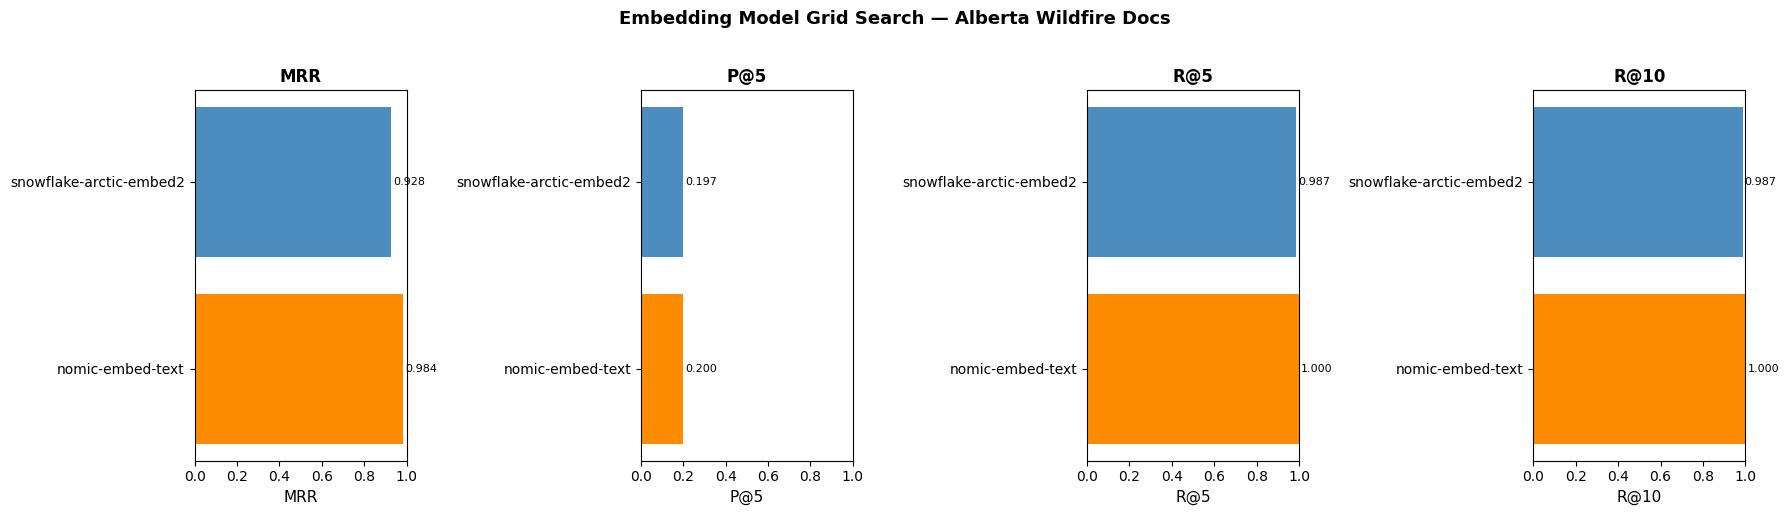

Saved: results/embedding_grid_search.png


In [41]:
# ── Analyse results ───────────────────────────────────────────────────────────
grid_df = pd.DataFrame(grid_results)
valid_df = grid_df.dropna(subset=["MRR"]).copy()

print("=== Full Results ===")
display(valid_df.set_index("model").drop(columns=["error"], errors="ignore").round(4))

# ── Pick best model (MRR primary, P@5 tiebreak) ───────────────────────────────
best_row  = valid_df.sort_values(["MRR", "P@5"], ascending=False).iloc[0]
BEST_MODEL = best_row["model"]
BEST_DIM   = int(best_row["dim"]) if "dim" in best_row else None

print(f"\n★ Best model : {BEST_MODEL}")
print(f"  MRR       : {best_row['MRR']:.4f}")
print(f"  P@5       : {best_row['P@5']:.4f}")
print(f"  R@5       : {best_row['R@5']:.4f}")
print(f"  Dim       : {BEST_DIM}")

# Save raw results
grid_df.to_csv(RESULTS_DIR / "embedding_grid_search.csv", index=False)
print("\nSaved: results/embedding_grid_search.csv")

# ── Plot ──────────────────────────────────────────────────────────────────────
metrics_plot = ["MRR", "P@5", "R@5", "R@10"]
metrics_plot = [m for m in metrics_plot if m in valid_df.columns]
ncols = len(metrics_plot)
fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 5))
if ncols == 1:
    axes = [axes]

model_labels = valid_df["model"].str.replace(":latest", "", regex=False)
colors = ["#FF8C00" if m == BEST_MODEL else "#4C8CBF" for m in valid_df["model"]]

for ax, metric in zip(axes, metrics_plot):
    bars = ax.barh(model_labels, valid_df[metric], color=colors)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, valid_df[metric]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=8)

fig.suptitle("Embedding Model Grid Search — Alberta Wildfire Docs",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "embedding_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/embedding_grid_search.png")

---
## Section 4 — Build & Save Vector Store

In [42]:
# ── Re-embed full corpus with best model ─────────────────────────────────────
print(f"Embedding {len(corpus_texts)} chunks with best model: {BEST_MODEL}")
best_vecs = embed_texts(corpus_texts, model=BEST_MODEL, show_progress=True)
print(f"Done. Shape: {best_vecs.shape}")

# Save embeddings as numpy array (fast reload for Neo4j section)
np.save(RESULTS_DIR / "best_embeddings.npy", best_vecs)
print(f"Saved: results/best_embeddings.npy")

Embedding 510 chunks with best model: nomic-embed-text:latest
    [nomic-embed-text] loading model (first call) ...
  ✓ nomic-embed-text               dim=768  [/api/embed]


Done. Shape: (510, 768)
Saved: results/best_embeddings.npy


In [43]:
# ── Build persistent ChromaDB vector store ────────────────────────────────────
VECTOR_STORE_DIR.mkdir(exist_ok=True)
chroma_client = chromadb.PersistentClient(path=str(VECTOR_STORE_DIR))

# Drop + recreate to allow re-runs
try:
    chroma_client.delete_collection("wildfire_docs")
    print("Dropped existing 'wildfire_docs' collection.")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="wildfire_docs",
    metadata={"hnsw:space": "cosine"},
)

# Add in batches
BATCH = 500
for i in range(0, len(all_chunks), BATCH):
    batch = all_chunks[i : i + BATCH]
    collection.add(
        ids        = [c["id"]       for c in batch],
        embeddings = best_vecs[i : i + BATCH].tolist(),
        documents  = [c["text"]     for c in batch],
        metadatas  = [{"source": c["source"], "doc_title": c["doc_title"]} for c in batch],
    )
    print(f"  Indexed {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

print(f"\nVector store persisted to: {VECTOR_STORE_DIR}")
print(f"Collection count: {collection.count()}")

Dropped existing 'wildfire_docs' collection.
  Indexed   500 / 510
  Indexed   510 / 510

Vector store persisted to: vector_store
Collection count: 510


In [44]:
# ── Save RAG configuration ────────────────────────────────────────────────────
rag_config = {
    "best_embedding_model":  BEST_MODEL,
    "embedding_dim":         int(best_vecs.shape[1]),
    "ollama_local_url":      OLLAMA_LOCAL_URL,
    "vector_store_path":     str(VECTOR_STORE_DIR),
    "chroma_collection":     "wildfire_docs",
    "total_chunks":          len(all_chunks),
    "pdf_files":             [p.name for p in pdf_files],
    "grid_search_summary":   grid_results,
}

with open(RESULTS_DIR / "rag_config.json", "w") as f:
    json.dump(rag_config, f, indent=2)

print("Saved: results/rag_config.json")
print(json.dumps({k: v for k, v in rag_config.items() if k != "grid_search_summary"}, indent=2))

Saved: results/rag_config.json
{
  "best_embedding_model": "nomic-embed-text:latest",
  "embedding_dim": 768,
  "ollama_local_url": "http://localhost:11434",
  "vector_store_path": "vector_store",
  "chroma_collection": "wildfire_docs",
  "total_chunks": 510,
  "pdf_files": [
    "7032001-2013-11-firesmart-guidebook-community-protection-guidebook-wildland-urban.pdf",
    "af-farm-and-acreage-guide-to-reducing-wildfire-risk-2020-08-25.pdf",
    "alberta-wildland-urban-interface-fires.pdf",
    "CWFIS_DataServices_HowtoAccessDailyMaps&DataLayers.pdf",
    "p-310-09-ho1-prevention-plan-template.pdf",
    "rmrs_gtr292.pdf"
  ]
}


---
## Section 5 — Neo4j Knowledge Graph

Starts a **Neo4j 5.x Docker container** automatically via the Python `docker` SDK, then builds the knowledge graph.

> **Requirements:** Docker must be running. The container `ember-neo4j` will be created on first run and reused on subsequent runs.

Graph schema:
```
(Document)-[:CONTAINS]->(Chunk)-[:MENTIONS]->(Concept)
(Concept)-[:RELATED_TO]->(Concept)      ← co-occurrence in same chunk
```
Chunks also carry an `embedding` property for Neo4j vector index search.

In [ ]:
# ── Start Neo4j via Docker (Python SDK) and connect ──────────────────────────
import docker as _docker

NEO4J_CONTAINER_NAME = "ember-neo4j"
NEO4J_IMAGE          = "neo4j:5"          # official Neo4j 5.x image
NEO4J_BOLT_PORT      = 7687
NEO4J_HTTP_PORT      = 7474
NEO4J_PASSWORD       = os.getenv("NEO4J_PASSWORD", "password")

neo4j_driver = None

def _ensure_neo4j_container() -> None:
    """Start the Neo4j Docker container if it isn't already running."""
    client = _docker.from_env()

    # Check if container already exists
    try:
        container = client.containers.get(NEO4J_CONTAINER_NAME)
        if container.status != "running":
            print(f"Starting existing container '{NEO4J_CONTAINER_NAME}' ...")
            container.start()
        else:
            print(f"Container '{NEO4J_CONTAINER_NAME}' already running.")
        return
    except _docker.errors.NotFound:
        pass

    # Pull image if needed and create container
    print(f"Creating Neo4j container '{NEO4J_CONTAINER_NAME}' (image: {NEO4J_IMAGE}) ...")
    container = client.containers.run(
        NEO4J_IMAGE,
        name=NEO4J_CONTAINER_NAME,
        detach=True,
        ports={
            f"{NEO4J_BOLT_PORT}/tcp": NEO4J_BOLT_PORT,
            f"{NEO4J_HTTP_PORT}/tcp": NEO4J_HTTP_PORT,
        },
        environment={
            "NEO4J_AUTH": f"neo4j/{NEO4J_PASSWORD}",
            "NEO4J_PLUGINS": '["graph-data-science"]',
        },
        restart_policy={"Name": "unless-stopped"},
    )
    print(f"  Container started: {container.short_id}")


def _wait_for_neo4j(uri: str, user: str, password: str, retries: int = 30, delay: float = 2.0):
    """Block until Neo4j responds to a connectivity check."""
    from neo4j import GraphDatabase
    print("Waiting for Neo4j to become ready ", end="", flush=True)
    for i in range(retries):
        try:
            drv = GraphDatabase.driver(uri, auth=(user, password))
            drv.verify_connectivity()
            print(" ready!")
            return drv
        except Exception:
            print(".", end="", flush=True)
            time.sleep(delay)
    raise RuntimeError(f"Neo4j did not become ready after {retries * delay:.0f}s")


# ── Main flow ─────────────────────────────────────────────────────────────────
try:
    _ensure_neo4j_container()
    neo4j_driver = _wait_for_neo4j(NEO4J_URI, NEO4J_USER, NEO4J_PASSWORD)
    print(f"✓ Neo4j connected: {NEO4J_URI}")
except Exception as e:
    print(f"✗ Neo4j setup failed: {e}")
    print("  → Sections 5 & 6-GRAG will be skipped; RAG-only assistant still works.")


def run_cypher(query: str, params: dict = {}) -> list:
    if neo4j_driver is None:
        raise RuntimeError("Neo4j not connected.")
    with neo4j_driver.session() as session:
        return [dict(r) for r in session.run(query, params)]

✗ Neo4j connection failed: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)
Failed to establish connection to ResolvedIPv4Address(('127.0.0.1', 7687)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)
  → Update NEO4J_PASSWORD in .env and re-run this cell.
  → Sections 5 & 6-GRAG will be skipped; RAG-only assistant still works.


In [4]:
if neo4j_driver:
    # ── Schema constraints ────────────────────────────────────────────────────
    schema_stmts = [
        "CREATE CONSTRAINT ember_doc_title IF NOT EXISTS FOR (d:Document) REQUIRE d.title IS UNIQUE",
        "CREATE CONSTRAINT ember_chunk_id  IF NOT EXISTS FOR (c:Chunk)    REQUIRE c.chunk_id IS UNIQUE",
        "CREATE CONSTRAINT ember_concept   IF NOT EXISTS FOR (co:Concept) REQUIRE co.name IS UNIQUE",
    ]
    for stmt in schema_stmts:
        try:
            run_cypher(stmt)
        except Exception as e:
            print(f"  Schema note: {e}")

    # ── Clean EMBER data to allow re-runs without duplicates ──────────────────
    run_cypher("MATCH (n) WHERE n.project = 'EMBER' DETACH DELETE n")
    print("Cleared previous EMBER nodes.")

    # ── Document nodes ────────────────────────────────────────────────────────
    for pdf_path in pdf_files:
        run_cypher(
            """
            MERGE (d:Document {title: $title})
            SET d.path = $path, d.project = 'EMBER', d.source = 'data_docs'
            """,
            {"title": pdf_path.stem[:80], "path": str(pdf_path)},
        )
    print(f"Created {len(pdf_files)} Document nodes.")

    # ── Chunk nodes + CONTAINS relationships ──────────────────────────────────
    print(f"Creating {len(all_chunks)} Chunk nodes ...")
    BATCH = 200
    for i in range(0, len(all_chunks), BATCH):
        batch = all_chunks[i : i + BATCH]
        run_cypher(
            """
            UNWIND $chunks AS c
            MERGE (ch:Chunk {chunk_id: c.id})
            SET ch.text      = c.text,
                ch.doc_title = c.doc_title,
                ch.project   = 'EMBER'
            WITH ch, c
            MATCH (d:Document {title: c.doc_title})
            MERGE (d)-[:CONTAINS]->(ch)
            """,
            {"chunks": batch},
        )
        print(f"  {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

    print("Chunk nodes created.")

NameError: name 'neo4j_driver' is not defined

In [5]:
if neo4j_driver:
    # ── Attach embeddings to Chunk nodes ─────────────────────────────────────
    # Load from saved file if best_vecs is not in memory
    if "best_vecs" not in dir() or best_vecs is None:
        best_vecs = np.load(RESULTS_DIR / "best_embeddings.npy")
    with open(RESULTS_DIR / "rag_config.json") as f:
        cfg = json.load(f)
    BEST_DIM = cfg["embedding_dim"]

    print(f"Attaching {len(all_chunks)} embeddings (dim={BEST_DIM}) to Chunk nodes ...")
    BATCH = 100
    for i in range(0, len(all_chunks), BATCH):
        batch_data = [
            {"id": all_chunks[j]["id"], "emb": best_vecs[j].tolist()}
            for j in range(i, min(i + BATCH, len(all_chunks)))
        ]
        run_cypher(
            """
            UNWIND $rows AS r
            MATCH (c:Chunk {chunk_id: r.id})
            SET c.embedding = r.emb
            """,
            {"rows": batch_data},
        )
        if (i // BATCH) % 5 == 0:
            print(f"  {min(i + BATCH, len(all_chunks)):>5} / {len(all_chunks)}")

    # ── Neo4j vector index (Neo4j 5.x) ───────────────────────────────────────
    try:
        run_cypher(
            f"""
            CREATE VECTOR INDEX ember_chunk_vectors IF NOT EXISTS
            FOR (c:Chunk) ON (c.embedding)
            OPTIONS {{indexConfig: {{
                `vector.dimensions`: {BEST_DIM},
                `vector.similarity_function`: 'cosine'
            }}}}
            """
        )
        print(f"Vector index 'ember_chunk_vectors' created (dim={BEST_DIM}).")
    except Exception as e:
        print(f"Vector index note (may already exist or Neo4j < 5.x): {e}")

NameError: name 'neo4j_driver' is not defined

In [6]:
if neo4j_driver:
    # ── Domain concepts for the wildfire knowledge graph ─────────────────────
    WILDFIRE_CONCEPTS = [
        ("Large Fire",               "Classification"),
        ("AUPRC",                    "Metric"),
        ("AUROC",                    "Metric"),
        ("Random Forest",            "Model"),
        ("Logistic Regression",      "Model"),
        ("Isolation Forest",         "Model"),
        ("SMOTE",                    "Technique"),
        ("SHAP",                     "Technique"),
        ("assessment hectares",      "Feature"),
        ("spread rate",              "Feature"),
        ("wind speed",               "Feature"),
        ("lightning",                "Cause"),
        ("prescribed fire",          "Technique"),
        ("FireSmart",                "Program"),
        ("Wildland-Urban Interface", "Concept"),
        ("fire weather index",       "Index"),
        ("CWFIS",                    "Dataset"),
        ("fire behaviour",           "Concept"),
        ("fuel management",          "Technique"),
        ("evacuation",               "Procedure"),
        ("Alberta Forest Protection","Organization"),
        ("fire suppression",         "Procedure"),
        ("detection lag",            "Feature"),
        ("dispatch lag",             "Feature"),
        ("Size Class D",             "Classification"),
        ("Size Class E",             "Classification"),
    ]

    # Create Concept nodes
    for name, ctype in WILDFIRE_CONCEPTS:
        run_cypher(
            "MERGE (c:Concept {name: $name}) SET c.type = $type, c.project = 'EMBER'",
            {"name": name, "type": ctype},
        )
    print(f"Created {len(WILDFIRE_CONCEPTS)} Concept nodes.")

    # Link Chunks → Concepts (text match)
    print("Linking chunks to concepts ...")
    for name, _ in tqdm(WILDFIRE_CONCEPTS):
        run_cypher(
            """
            MATCH (ch:Chunk {project: 'EMBER'}), (co:Concept {name: $name})
            WHERE toLower(ch.text) CONTAINS toLower($name)
            MERGE (ch)-[:MENTIONS]->(co)
            """,
            {"name": name},
        )

    # Co-occurrence → RELATED_TO
    run_cypher(
        """
        MATCH (c1:Concept)<-[:MENTIONS]-(ch:Chunk)-[:MENTIONS]->(c2:Concept)
        WHERE id(c1) < id(c2)
        MERGE (c1)-[:RELATED_TO]->(c2)
        """
    )
    print("Concept relationships created.")

    # ── Verify graph ──────────────────────────────────────────────────────────
    print("\n── Graph Summary ──")
    for label in ["Document", "Chunk", "Concept"]:
        n = run_cypher(f"MATCH (n:{label} {{project:'EMBER'}}) RETURN count(n) AS c")[0]["c"]
        print(f"  {label:<12}: {n}")
    for rel in ["CONTAINS", "MENTIONS", "RELATED_TO"]:
        n = run_cypher(
            f"MATCH (a {{project:'EMBER'}})-[r:{rel}]->(b) RETURN count(r) AS c"
        )[0]["c"]
        print(f"  :{rel:<14}: {n}")

NameError: name 'neo4j_driver' is not defined

---
## Section 6 — Agentic RAG / GRAG Assistant

A **ReAct** (Reason + Act) agent loop that can:
| Tool | Type | What it does |
|---|---|---|
| `rag_retrieve` | RAG | Cosine search over ChromaDB vector store |
| `grag_vector_search` | GRAG | Neo4j vector index search (semantic) |
| `grag_concept_neighbors` | GRAG | Graph traversal from a concept |
| `grag_concept_chunks` | GRAG | Chunks that mention a concept |
| `grag_graph_summary` | GRAG | High-level graph statistics |

The agent picks tools autonomously, observes results, and synthesises a final answer.

In [46]:
# ── Load saved config + collection (safe to run independently) ────────────────
with open(RESULTS_DIR / "rag_config.json") as f:
    rag_config = json.load(f)

BEST_MODEL = rag_config["best_embedding_model"]
BEST_DIM   = rag_config["embedding_dim"]

# Reload ChromaDB
_chroma = chromadb.PersistentClient(path=str(VECTOR_STORE_DIR))
collection = _chroma.get_collection("wildfire_docs")

print(f"Vector store loaded  : {collection.count()} chunks")
print(f"Best embedding model : {BEST_MODEL}  (dim={BEST_DIM})")
print(f"LLM for agent        : {AGENT_LLM}")

Vector store loaded  : 510 chunks
Best embedding model : nomic-embed-text:latest  (dim=768)
LLM for agent        : llama3.1:8b


In [47]:

# ── Tool definitions ──────────────────────────────────────────────────────────

# ── 1. predict_fire_risk ──────────────────────────────────────────────────────
def predict_fire_risk(inputs_json: str) -> str:
    """
    Predict large-fire probability from a JSON string of fire conditions.

    Required keys (all numeric):
      ASSESSMENT_HECTARES, FIRE_SPREAD_RATE, WIND_SPEED, CAUSE_BINARY,
      TEMPERATURE, FOREST_AREA_ENC, FIRE_TYPE_ENC, DISPATCH_LAG_HRS,
      FUEL_TYPE_ENC, RELATIVE_HUMIDITY, FIRE_MONTH, DETECTION_LAG_HRS

    Returns a plain-text risk assessment string.
    """
    import json as _json

    # Parse inputs
    try:
        inputs = _json.loads(inputs_json) if isinstance(inputs_json, str) else inputs_json
    except Exception as e:
        return f"Error parsing inputs JSON: {e}"

    # Ensure models are loaded
    load_ml_models()

    if _ml_scaler is None:
        return (
            "MISSING: scaler.pkl not found in results/. "
            "Run the Section 1b regeneration cell with your training data Excel file."
        )

    # Build and scale feature vector
    try:
        row = np.array([[float(inputs.get(f, 0.0)) for f in FEATURE_ORDER]])
        X_sc = _ml_scaler.transform(row)
    except Exception as e:
        return f"Error building feature vector: {e}"

    # Run available models
    probs: Dict[str, float] = {}
    if _rf_model is not None:
        probs["Random Forest"] = float(_rf_model.predict_proba(X_sc)[0, 1])
    if _lr_model is not None:
        probs["Logistic Regression"] = float(_lr_model.predict_proba(X_sc)[0, 1])

    if not probs:
        return "No ML models loaded — cannot predict."

    ensemble = sum(probs.values()) / len(probs)

    if ensemble < 0.10:
        risk_level, risk_desc = "LOW",       "Conditions are not strongly indicative of a large fire."
    elif ensemble < 0.25:
        risk_level, risk_desc = "MODERATE",  "Some risk factors present; monitor closely."
    elif ensemble < 0.45:
        risk_level, risk_desc = "HIGH",      "Multiple risk factors elevated; consider pre-emptive action."
    else:
        risk_level, risk_desc = "VERY HIGH", "Conditions strongly associated with large-fire escalation."

    lines = [
        "=== EMBER FIRE RISK PREDICTION ===",
        f"Ensemble probability : {ensemble:.1%}  →  {risk_level} RISK",
        f"Interpretation       : {risk_desc}",
        "",
    ]
    for name, prob in probs.items():
        lines.append(f"  {name:<24}: {prob:.1%}")
    lines += [
        "",
        "Key inputs provided:",
    ]
    for k, v in inputs.items():
        lines.append(f"  {k}: {v}")
    lines += [
        "",
        "Note: class imbalance (3.3% positive rate) means probabilities are calibrated",
        "relative to the historical base rate. Values above ~10% should be treated seriously.",
    ]
    return "\n".join(lines)


# ── 2. rag_retrieve ───────────────────────────────────────────────────────────
def rag_retrieve(query: str, k: int = 5) -> str:
    """Retrieve top-k relevant document chunks from the ChromaDB vector store."""
    q_vec = embed_texts([query], model=BEST_MODEL)[0].tolist()
    res = collection.query(
        query_embeddings=[q_vec],
        n_results=k,
        include=["documents", "metadatas", "distances"],
    )
    parts = []
    for i, (doc, meta, dist) in enumerate(
        zip(res["documents"][0], res["metadatas"][0], res["distances"][0])
    ):
        parts.append(
            f"[Source {i+1} | {meta['doc_title']} | score={1-dist:.3f}]\n"
            + doc[:500]
        )
    return "\n\n".join(parts)


# ── 3. grag_vector_search ─────────────────────────────────────────────────────
def grag_vector_search(query: str, k: int = 5) -> str:
    """Semantic search directly in Neo4j using the vector index, then traverse graph context."""
    if neo4j_driver is None:
        return "Neo4j not connected — use rag_retrieve instead."
    q_vec = embed_texts([query], model=BEST_MODEL)[0].tolist()
    try:
        rows = run_cypher(
            """
            CALL db.index.vector.queryNodes('ember_chunk_vectors', $k, $vec)
            YIELD node AS ch, score
            MATCH (d:Document)-[:CONTAINS]->(ch)
            OPTIONAL MATCH (ch)-[:MENTIONS]->(co:Concept)
            RETURN d.title AS doc, ch.text AS text, score,
                   collect(co.name) AS concepts
            """,
            {"k": k, "vec": q_vec},
        )
    except Exception as e:
        return f"Graph vector search unavailable ({e}). Use rag_retrieve."
    if not rows:
        return "No results from graph vector search."
    parts = []
    for i, r in enumerate(rows):
        concepts = ", ".join(r["concepts"]) if r["concepts"] else "none"
        parts.append(
            f"[Source {i+1} | {r['doc']} | score={r['score']:.3f}]\n"
            f"Concepts: {concepts}\n"
            + r["text"][:500]
        )
    return "\n\n".join(parts)


# ── 4. grag_concept_neighbors ─────────────────────────────────────────────────
def grag_concept_neighbors(concept_name: str) -> str:
    """Find concepts related to a given concept via graph co-occurrence."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    rows = run_cypher(
        """
        MATCH (c:Concept)-[:RELATED_TO]-(c2:Concept)
        WHERE toLower(c.name) CONTAINS toLower($name)
        RETURN c.name AS source, c2.name AS neighbor, c2.type AS type
        ORDER BY c2.name LIMIT 25
        """,
        {"name": concept_name},
    )
    if not rows:
        return f"No related concepts found for '{concept_name}'."
    return "\n".join(f"  {r['source']} ↔ {r['neighbor']} ({r['type']})" for r in rows)


# ── 5. grag_concept_chunks ────────────────────────────────────────────────────
def grag_concept_chunks(concept_name: str) -> str:
    """Retrieve document chunks mentioning a concept via graph traversal."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    rows = run_cypher(
        """
        MATCH (co:Concept)<-[:MENTIONS]-(ch:Chunk)<-[:CONTAINS]-(d:Document)
        WHERE toLower(co.name) CONTAINS toLower($name)
        RETURN d.title AS doc, ch.text AS text LIMIT 4
        """,
        {"name": concept_name},
    )
    if not rows:
        return f"No chunks found mentioning '{concept_name}'."
    return "\n\n".join(f"[{r['doc']}]\n{r['text'][:500]}" for r in rows)


# ── 6. grag_graph_summary ─────────────────────────────────────────────────────
def grag_graph_summary() -> str:
    """Return a high-level summary of the knowledge graph."""
    if neo4j_driver is None:
        return "Neo4j not connected."
    docs = run_cypher(
        "MATCH (d:Document {project:'EMBER'}) "
        "RETURN d.title AS title, size((d)-[:CONTAINS]->()) AS chunks"
    )
    lines = [f"  - {r['title']} ({r['chunks']} chunks)" for r in docs]
    return "Documents in graph:\n" + "\n".join(lines)


TOOLS: Dict[str, callable] = {
    "predict_fire_risk":      predict_fire_risk,
    "rag_retrieve":           rag_retrieve,
    "grag_vector_search":     grag_vector_search,
    "grag_concept_neighbors": grag_concept_neighbors,
    "grag_concept_chunks":    grag_concept_chunks,
    "grag_graph_summary":     grag_graph_summary,
}

print("Tools registered:", list(TOOLS.keys()))


Tools registered: ['predict_fire_risk', 'rag_retrieve', 'grag_vector_search', 'grag_concept_neighbors', 'grag_concept_chunks', 'grag_graph_summary']


In [48]:

# ── LLM helper ── ─────────────────────────────────────────────────────────────
def llm_call(prompt: str, model: str = AGENT_LLM) -> str:
    resp = requests.post(
        f"{OLLAMA_LOCAL_URL}/api/generate",
        json={"model": model, "prompt": prompt, "stream": False},
        timeout=180,
    )
    resp.raise_for_status()
    return resp.json()["response"].strip()


# ── ReAct agent ───────────────────────────────────────────────────────────────
SYSTEM_PROMPT = """You are EMBER — an expert wildfire risk analyst assistant for Alberta, Canada.

You have access to predictive ML models and a document retrieval system.

Available tools:
  predict_fire_risk('<json>')           — run ML models to predict large-fire probability
                                          JSON keys: ASSESSMENT_HECTARES, FIRE_SPREAD_RATE,
                                          WIND_SPEED, CAUSE_BINARY (0/1), TEMPERATURE,
                                          FOREST_AREA_ENC, FIRE_TYPE_ENC, DISPATCH_LAG_HRS,
                                          FUEL_TYPE_ENC, RELATIVE_HUMIDITY, FIRE_MONTH,
                                          DETECTION_LAG_HRS
  rag_retrieve("<query>")               — semantic search over mitigation document chunks
  grag_vector_search("<query>")         — semantic search via Neo4j graph index
  grag_concept_neighbors("<concept>")   — related concepts in knowledge graph
  grag_concept_chunks("<concept>")      — document chunks mentioning a concept
  grag_graph_summary()                  — list all documents in graph

Rules:
- Think step by step.
- When the user asks for a fire risk prediction AND provides numerical inputs, call predict_fire_risk FIRST.
- After getting a prediction, always follow up with rag_retrieve to provide mitigation guidance.
- For general mitigation questions, use rag_retrieve or grag_vector_search.
- For conceptual/relational questions, combine grag_concept_neighbors + grag_concept_chunks.
- To call a tool write EXACTLY:  ACTION: tool_name("argument")
- For JSON arguments:            ACTION: predict_fire_risk('{"ASSESSMENT_HECTARES": 5.0, ...}')
- For no-argument tools write:   ACTION: grag_graph_summary()
- When you have enough information write:  FINAL ANSWER: <your answer>

Always end your response with actionable, specific guidance the user can act on.
"""


def _parse_action(text: str) -> Tuple[Optional[str], Optional[str]]:
    """Extract tool_name, argument from an ACTION line."""
    # Handle JSON arguments with single or double quotes wrapping
    m = re.search(r"ACTION:\s*(\w+)\('(.+?)'\)", text, re.DOTALL)
    if m:
        return m.group(1), m.group(2)
    m = re.search(r'ACTION:\s*(\w+)\("(.+?)"\)', text, re.DOTALL)
    if m:
        return m.group(1), m.group(2)
    m = re.search(r'ACTION:\s*(\w+)\(\)', text)
    if m:
        return m.group(1), ""
    return None, None


def react_agent(
    question: str,
    max_steps: int = 8,
    verbose: bool = True,
) -> str:
    """Run the ReAct loop and return the final answer."""
    sep = "═" * 72
    if verbose:
        print(f"\n{sep}")
        print(f"QUESTION: {question}")
        print(sep)

    history = [f"QUESTION: {question}"]

    for step in range(max_steps):
        prompt = SYSTEM_PROMPT + "\n\n" + "\n".join(history) + "\n\nTHOUGHT:"
        response = llm_call(prompt)

        if verbose:
            print(f"\n[Step {step + 1}]")
            print(textwrap.fill(response[:400], width=90, subsequent_indent="  "))

        history.append(f"THOUGHT: {response}")

        # Final answer?
        if "FINAL ANSWER:" in response:
            answer = response.split("FINAL ANSWER:", 1)[-1].strip()
            if verbose:
                print(f"\n{sep}")
                print("FINAL ANSWER:")
                print(textwrap.fill(answer, width=90))
            return answer

        # Parse + execute tool
        tool_name, arg = _parse_action(response)
        if tool_name and tool_name in TOOLS:
            try:
                obs = TOOLS[tool_name](arg) if arg else TOOLS[tool_name]()
                obs = obs[:1500]          # cap observation length
            except Exception as e:
                obs = f"Tool error: {e}"
            if verbose:
                print(f"\n  → OBSERVATION from {tool_name}():")
                print(textwrap.indent(obs[:600], "    "))
            history.append(f'ACTION: {tool_name}("{arg}")')
            history.append(f"OBSERVATION: {obs}")
        else:
            history.append("THOUGHT: I should now provide a final answer.")

    # Fallback if max steps reached
    prompt = SYSTEM_PROMPT + "\n\n" + "\n".join(history) + "\n\nFINAL ANSWER:"
    return llm_call(prompt)


print("ReAct agent ready.")
print(f"Agent LLM : {AGENT_LLM}")
print(f"Tools     : {list(TOOLS.keys())}")


ReAct agent ready.
Agent LLM : llama3.1:8b
Tools     : ['predict_fire_risk', 'rag_retrieve', 'grag_vector_search', 'grag_concept_neighbors', 'grag_concept_chunks', 'grag_graph_summary']


In [49]:

# ── Test questions ────────────────────────────────────────────────────────────
TEST_QUESTIONS = [
    # Prediction + mitigation (end-to-end test)
    (
        "I have a fire that is currently 8 hectares, spreading at 45 m/min, with 60 km/h winds, "
        "lightning-caused, temperature 32°C, forest area code 1, fire type 0, dispatch lag 2 hours, "
        "fuel type 3, relative humidity 18%, ignition in July, detection lag 1 hour. "
        "What is the probability this becomes a large fire and what should I do?"
    ),
    # Mitigation-only questions
    "What are the main causes of large wildfires in Alberta and how can communities prepare?",
    "What strategies does FireSmart recommend for reducing wildfire risk at Wildland-Urban Interface?",
    "How does wind speed affect wildfire behaviour and escalation risk?",
    "What data layers and services does CWFIS provide for wildfire monitoring?",
]

# Run the first test question (prediction + mitigation)
answer = react_agent(TEST_QUESTIONS[0], verbose=True)



════════════════════════════════════════════════════════════════════════
QUESTION: I have a fire that is currently 8 hectares, spreading at 45 m/min, with 60 km/h winds, lightning-caused, temperature 32°C, forest area code 1, fire type 0, dispatch lag 2 hours, fuel type 3, relative humidity 18%, ignition in July, detection lag 1 hour. What is the probability this becomes a large fire and what should I do?
════════════════════════════════════════════════════════════════════════

[Step 1]
Let's break down the question step by step:  1. The user provides numerical inputs for the
  wildfire characteristics. Since they're asking for a fire risk prediction with specific
  input values, we'll call `predict_fire_risk` first.  ACTION:
  predict_fire_risk('{"ASSESSMENT_HECTARES": 8.0, "FIRE_SPREAD_RATE": 45, "WIND_SPEED":
  60, "CAUSE_BINARY": 1, "TEMPERATURE": 32, "FOREST_AREA_ENC": 1, "FIRE_TYPE
  Random Forest         : ✓ loaded  (wildfire_model.pkl)
  Logistic Regression   : ✓ loaded  (lr_m

In [50]:
# ── Run remaining test questions ──────────────────────────────────────────────
for q in TEST_QUESTIONS[1:]:
    react_agent(q, verbose=True)
    print()


════════════════════════════════════════════════════════════════════════
QUESTION: What are the main causes of large wildfires in Alberta and how can communities prepare?
════════════════════════════════════════════════════════════════════════

[Step 1]
ACTION: grag_concept_neighbors("large wildfires")   (This will help me understand related
  concepts to large wildfires)  Also, for general mitigation questions like this one, it's
  best to combine the output from concept neighbors with document chunks mentioning these
  concepts. However, since we're looking for causes and preparation advice, a graph-based
  search should suffice.  Now let's see if ther

  → OBSERVATION from grag_concept_neighbors():
    Tool error: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
    Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)
    Faile

In [51]:
# ── Interactive assistant ─────────────────────────────────────────────────────
# Call ask("your question") to query the agent at any time.

def ask(question: str, verbose: bool = True) -> str:
    """Ask the RAG/GRAG agent a question."""
    return react_agent(question, verbose=verbose)


# ── Example ───────────────────────────────────────────────────────────────────
ask("What are best practices for farm owners to reduce wildfire ignition risk near buildings?")


════════════════════════════════════════════════════════════════════════
QUESTION: What are best practices for farm owners to reduce wildfire ignition risk near buildings?
════════════════════════════════════════════════════════════════════════

[Step 1]
To address the question about best practices for reducing wildfire ignition risk near farm
  buildings, I'll combine grag_concept_neighbors and grag_concept_chunks.  ACTION:
  grag_concept_neighbors("wildfire ignition prevention")  This will give me related
  concepts in the knowledge graph, which can inform my understanding of what mitigation
  strategies might be effective.  Next, to understand where th

  → OBSERVATION from grag_concept_neighbors():
    Tool error: Couldn't connect to localhost:7687 (resolved to ('[::1]:7687', '127.0.0.1:7687')):
    Failed to establish connection to ResolvedIPv6Address(('::1', 7687, 0, 0)) (reason [WinError 10061] No connection could be made because the target machine actively refused it)
    Fail

'To reduce wildfire ignition risk near farm buildings, farm owners should maintain a 3-meter wide defensible space around all outbuildings, including clearing flammable materials and keeping grass short by mowing regularly.\n\nACTIVABLE GUIDANCE: Perform regular maintenance to clear dead leaves, branches, and weeds from the area surrounding farm buildings. Mow grass regularly, especially during dry seasons.'